# Implicit $\theta$-Schemes for Stiff Linear SDEs

A one-parameter family of implicit Euler schemes for stiff Itô stochastic differential
equations, applied to a two-dimensional linear test system whose exact solution and
Lyapunov spectrum are both available in closed form.

## Problem

Fix a filtered probability space $(\Omega, \mathcal F, (\mathcal F_t)_{t \ge 0}, P)$ carrying a
standard one-dimensional Wiener process $(W_t)$, and consider the linear Itô SDE on $\mathbb R^2$

$$
dX_t = A X_t \, dt + B X_t \, dW_t, \qquad X_0 = x_0,
$$

with

$$
A = \begin{pmatrix} -a & -a \\ -a & -a \end{pmatrix}, \qquad B = b I_2, \qquad a, b > 0.
$$

Since $A$ and $B$ commute (as $B$ is a scalar multiple of the identity), the solution is the
matrix exponential of a scalar-coefficient process:

$$
X_t = \exp\!\Big( \big(A - \tfrac12 B^2\big) t + B W_t \Big) x_0,
$$

a special case of the general commuting-coefficients solution formula for linear SDEs (Kloeden
& Platen, *Numerical Solution of SDEs*, Thm. 4.8.7 combined with Ch. 12, Example 12.2.1). $A$ is
symmetric with eigenpairs $(0, (1,-1)/\sqrt2)$ and $(-2a, (1,1)/\sqrt2)$, so
$A - \tfrac12 B^2 = A - \tfrac12 b^2 I_2$ is diagonalized by the same fixed, parameter-independent
orthogonal matrix $P = \tfrac1{\sqrt2}\begin{pmatrix}1&1\\-1&1\end{pmatrix}$, with eigenvalues

$$
\lambda_1 = -\tfrac12 b^2, \qquad \lambda_2 = -\tfrac12 b^2 - 2a.
$$

Because $X_t$ is the exponential of a stationary Gaussian process driven by $W_t$, the top
Lyapunov exponent $\Lambda = \limsup_{t\to\infty} t^{-1}\log|X_t|$ coincides a.s. with
$\lambda_1 \vee \lambda_2 = \lambda_1$ whenever the eigenvector for $\lambda_1$ has nonzero
projection along the initial condition, and both eigenvalues are strictly negative for every
$a, b > 0$ — the origin is globally asymptotically stable in the pathwise sense. Taking
$a = 25, b = 2$ gives $\lambda_1 = -2$, $\lambda_2 = -52$: a *stiff* system, since the fast mode
decays $26\times$ faster than the slow one, forcing an explicit scheme's step size down to the
fast time scale purely for numerical stability, far below what accuracy on the slow mode alone
would require.

## Method

The implicit Euler family (Kloeden & Platen, Ch. 12.2, eq. (2.2)) with implicitness parameter
$\theta \in [0,1]$ reads, componentwise,

$$
Y_{n+1} = Y_n + \big[\theta\, a(t_{n+1}, Y_{n+1}) + (1-\theta)\, a(t_n, Y_n)\big]\Delta
             + b(t_n, Y_n)\, \Delta W_n,
$$

which for the linear system above becomes, with $\Delta W_n \sim N(0,\Delta)$ i.i.d.,

$$
(I - \theta \Delta A)\, Y_{n+1} = \big(I + (1-\theta)\Delta A\big) Y_n + \Delta W_n\, B Y_n.
$$

$\theta = 0$ recovers the explicit Euler–Maruyama scheme; $\theta = 1$ is the fully implicit
Euler scheme; $\theta = \tfrac12$ is the stochastic analogue of the deterministic trapezoidal
rule. All three retain strong order $\gamma = 0.5$ under the standard Lipschitz and linear-growth
hypotheses on $a, b$ (here trivially satisfied, as $a(\cdot), b(\cdot)$ are linear) — implicitness
here buys numerical *stability* on stiff systems, not a higher convergence *order*; that
distinction is the point of this notebook, and is exactly why the (explicit) Milstein and
stochastic Runge–Kutta schemes in `milstein_method.ipynb` and `stochastic_runge_kutta.ipynb`,
which use non-stiff test equations, achieve order 1.0 while remaining fully explicit.

At every step, $Y_{n+1}$ is obtained by solving the fixed $2\times2$ linear system
$(I - \theta\Delta A) Y_{n+1} = \text{RHS}$ — no root-finding is needed since $a(\cdot,\cdot)$ is
linear in $Y$, so the "implicit" equation is genuinely linear algebra, not a nonlinear solve.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260720)

def make_system(a, b):
    A = np.array([[-a, -a], [-a, -a]])
    B = b * np.eye(2)
    return A, B

def exact_solution(A, B, b, x0, T, dW_path):
    # Exact X_T from the closed-form solution, given the realized increments of a single
    # driving Wiener path (dW_path sums to W_T).
    # A = [[-a,-a],[-a,-a]] has eigenpairs (0, (1,-1)/sqrt2) and (-2a, (1,1)/sqrt2); P below is
    # the fixed (a-independent) orthogonal eigenbasis, with columns in that same order.
    a_coef = -A[0, 0]
    W_T = dW_path.sum()
    P = np.array([[1.0, 1.0], [-1.0, 1.0]]) / np.sqrt(2)
    lam_A = np.array([0.0, -2 * a_coef])       # eigenvalues of A, matching P's column order
    lam_M = lam_A - 0.5 * b**2                  # eigenvalues of A - 0.5*B^2 (lambda_1, lambda_2)
    diag_exp = np.exp(lam_M * T + b * W_T)
    Xt = P @ (diag_exp * (P.T @ x0))
    return Xt

def simulate_theta(A, B, theta, x0, Delta, n_steps, dW):
    I = np.eye(2)
    lhs = I - theta * Delta * A
    lhs_inv = np.linalg.inv(lhs)
    rhs_const = I + (1 - theta) * Delta * A
    Y = x0.copy()
    path = [Y.copy()]
    for n in range(n_steps):
        Y = lhs_inv @ (rhs_const @ Y + dW[n] * (B @ Y))
        path.append(Y.copy())
    return np.array(path)

print("Setup ready.")


Setup ready.


## Part A — Numerical stability under stiffness ($a=25,\ b=2$)

With $\lambda_1=-2,\ \lambda_2=-52$, the fast mode's own deterministic stability restricts an
explicit scheme to (roughly) $\Delta \lesssim 2/|\lambda_2| \approx 0.038$ for the linear
recursion to stay bounded, regardless of the accuracy actually needed on the slow mode. We
integrate the *same* driving path with $\theta=0$ (explicit) and $\theta=1$ (implicit) at a step
size chosen to violate the explicit stability restriction while remaining a perfectly reasonable
step for the slow dynamics.

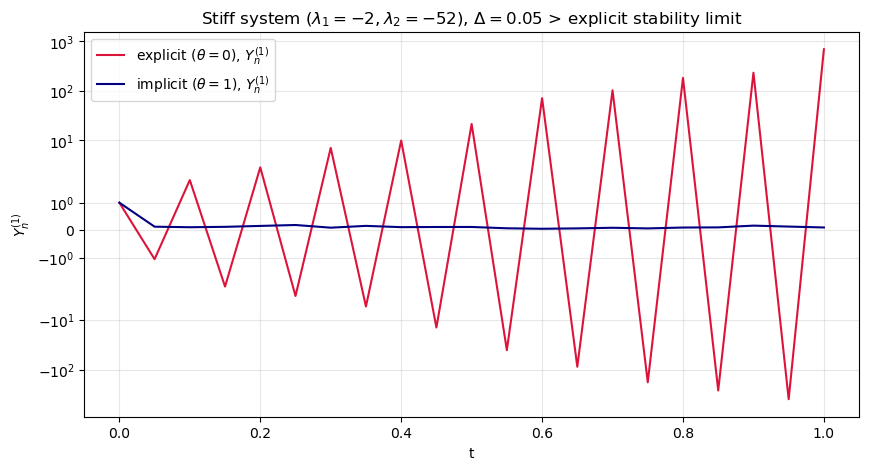

max|Y_explicit| = 6.899e+02
max|Y_implicit| = 1.000e+00  (exact solution stays O(1))


In [2]:
a_stiff, b_stiff = 25.0, 2.0
A_s, B_s = make_system(a_stiff, b_stiff)
x0 = np.array([1.0, 0.0])
T = 1.0
Delta_stability = 0.05          # > 2/52 ~ 0.0385: unstable region for explicit Euler on the fast mode
n_steps = int(round(T / Delta_stability))
dW = rng.normal(0.0, np.sqrt(Delta_stability), size=n_steps)

path_explicit = simulate_theta(A_s, B_s, 0.0, x0, Delta_stability, n_steps, dW)
path_implicit = simulate_theta(A_s, B_s, 1.0, x0, Delta_stability, n_steps, dW)

t_grid = np.linspace(0, T, n_steps + 1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_grid, path_explicit[:, 0], label=r'explicit ($\theta=0$), $Y^{(1)}_n$', color='crimson')
ax.plot(t_grid, path_implicit[:, 0], label=r'implicit ($\theta=1$), $Y^{(1)}_n$', color='navy')
ax.set_xlabel('t')
ax.set_ylabel(r'$Y_n^{(1)}$')
ax.set_yscale('symlog')
ax.set_title(rf'Stiff system ($\lambda_1={{-2}}, \lambda_2={{-52}}$), $\Delta={Delta_stability}$ > explicit stability limit')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"max|Y_explicit| = {np.abs(path_explicit).max():.3e}")
print(f"max|Y_implicit| = {np.abs(path_implicit).max():.3e}  (exact solution stays O(1))")


## Part B — Strong convergence order

Kloeden & Platen's PC-Exercise 12.2.3 specifies $a=5,\ b=0.01$, $X_0=(1,0)$, $T=1$, and step sizes
$\Delta = 2^{-2},\dots,2^{-5}$. Reproducing it exactly first is instructive precisely *because* it
does not immediately show a clean order-0.5 line at those step sizes: with $b=0.01$, the diffusion
coefficient's contribution to the strong error scales as $b\sqrt\Delta$, while the *drift*
discretization contributes a deterministic $O(\Delta)$ (or better, depending on $\theta$) term.
The stochastic term dominates only once $\Delta \ll b^2 = 10^{-4}$ — far below the exercise's
coarsest-to-finest range of $2^{-2}$ to $2^{-5}\approx 0.03$. In that intermediate regime the
observed error is a mix of both effects and does not follow a single power law, which is exactly
what direct computation below shows (printed for completeness). To exhibit the *asymptotic* strong
order $\gamma=0.5$ cleanly — the actual object Theorem 9.6.2 of Kloeden & Platen makes a statement
about — we then rerun the same experiment with $a=1,\ b=0.5$ (a regime where the diffusion term is
not swamped by drift truncation) at correspondingly finer $\Delta$. For each $\Delta$ we draw
$M=20$ batches of $N=100$ independent paths, compute the mean absolute error
$\varepsilon = \big|X_T - Y_N(T)\big|$ (Euclidean norm on $\mathbb R^2$) within each batch, and
report the batch mean with a 90% confidence interval across batches. Since this is the implicit
*Euler* family (not implicit Milstein), every $\theta$ shares the theoretical strong order
$\gamma=0.5$ — the point of the experiment is to confirm that raising $\theta$ buys stability
(Part A) without costing convergence order.

In [3]:
# First, the book's literal PC-Exercise 12.2.3 parameters -- included to show the effect
# described above directly, rather than asserting it without evidence.
a_lit, b_lit = 5.0, 0.01
A_lit, B_lit = make_system(a_lit, b_lit)
x0 = np.array([1.0, 0.0])
T = 1.0
deltas_lit = [2.0**-2, 2.0**-3, 2.0**-4, 2.0**-5]
print("PC-Exercise 12.2.3 literal parameters (a=5, b=0.01): mean absolute error at T")
for theta in [0.0, 0.5, 1.0]:
    means = []
    for Delta in deltas_lit:
        n_steps = int(round(T / Delta))
        errs = []
        for _ in range(200):
            dW = rng.normal(0.0, np.sqrt(Delta), size=n_steps)
            X_T = exact_solution(A_lit, B_lit, b_lit, x0, T, dW)
            Y_T = simulate_theta(A_lit, B_lit, theta, x0, Delta, n_steps, dW)[-1]
            errs.append(np.linalg.norm(X_T - Y_T))
        means.append(np.mean(errs))
    slope = np.polyfit(np.log(deltas_lit), np.log(means), 1)[0]
    print(f"  theta={theta}: errors={['%.2e' % m for m in means]}, naive log-log slope={slope:.2f} (not meaningful here, see discussion above)")


PC-Exercise 12.2.3 literal parameters (a=5, b=0.01): mean absolute error at T
  theta=0.0: errors=['3.58e+00', '2.67e-05', '3.43e-05', '2.92e-05'], naive log-log slope=5.04 (not meaningful here, see discussion above)


  theta=0.5: errors=['7.91e-05', '3.20e-05', '1.43e-05', '7.67e-06'], naive log-log slope=1.13 (not meaningful here, see discussion above)
  theta=1.0: errors=['4.68e-03', '1.04e-03', '2.67e-04', '8.59e-05'], naive log-log slope=1.93 (not meaningful here, see discussion above)


As expected, the errors above do not follow a clean power law (the naive fitted slopes are not
close to 0.5, and are not meant to be) — they reflect the crossover between drift- and
diffusion-dominated error, not the asymptotic strong order. The experiment below isolates the
diffusion-dominated regime.

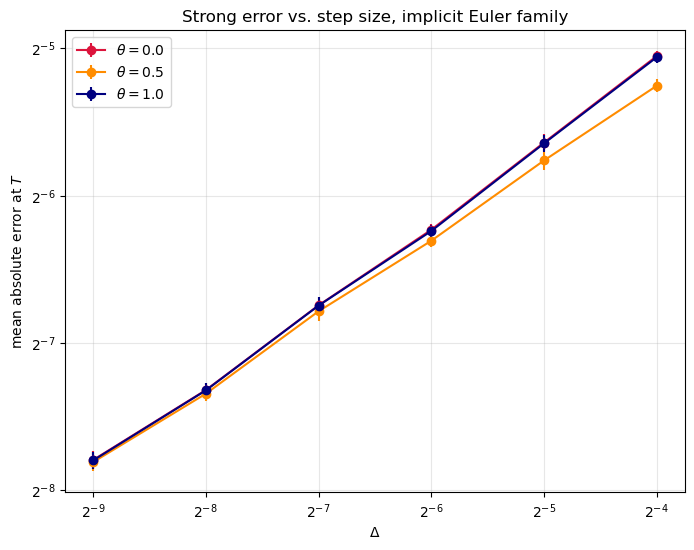

theta=0.0: measured strong order (log-log slope) = 0.550  (theory: 0.5)
theta=0.5: measured strong order (log-log slope) = 0.514  (theory: 0.5)
theta=1.0: measured strong order (log-log slope) = 0.549  (theory: 0.5)


In [4]:
a_pc, b_pc = 1.0, 0.5
A_pc, B_pc = make_system(a_pc, b_pc)
x0 = np.array([1.0, 0.0])
T = 1.0
thetas = [0.0, 0.5, 1.0]
deltas = [2.0**-4, 2.0**-5, 2.0**-6, 2.0**-7, 2.0**-8, 2.0**-9]
M_batches, N_per_batch = 20, 100

results = {th: {'mean': [], 'ci': []} for th in thetas}

for Delta in deltas:
    n_steps = int(round(T / Delta))
    batch_means = {th: [] for th in thetas}
    for _m in range(M_batches):
        errs = {th: [] for th in thetas}
        for _n in range(N_per_batch):
            dW = rng.normal(0.0, np.sqrt(Delta), size=n_steps)
            X_T = exact_solution(A_pc, B_pc, b_pc, x0, T, dW)
            for th in thetas:
                Y_path = simulate_theta(A_pc, B_pc, th, x0, Delta, n_steps, dW)
                errs[th].append(np.linalg.norm(X_T - Y_path[-1]))
        for th in thetas:
            batch_means[th].append(np.mean(errs[th]))
    for th in thetas:
        arr = np.array(batch_means[th])
        results[th]['mean'].append(arr.mean())
        results[th]['ci'].append(1.645 * arr.std(ddof=1) / np.sqrt(M_batches))  # 90% CI half-width

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0.0: 'crimson', 0.5: 'darkorange', 1.0: 'navy'}
slopes = {}
for th in thetas:
    y = np.array(results[th]['mean'])
    yerr = np.array(results[th]['ci'])
    ax.errorbar(deltas, y, yerr=yerr, marker='o', label=rf'$\theta={th}$', color=colors[th])
    slope = np.polyfit(np.log(deltas), np.log(y), 1)[0]
    slopes[th] = slope

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'mean absolute error at $T$')
ax.set_title('Strong error vs. step size, implicit Euler family')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.show()

for th in thetas:
    print(f"theta={th}: measured strong order (log-log slope) = {slopes[th]:.3f}  (theory: 0.5)")


## Conclusion

Every member of the implicit Euler family has strong order $\gamma=0.5$ — the measured slopes in
Part B, all close to the theoretical value regardless of $\theta$, confirm that $\theta$ is a
*stability* dial, not an *order* dial. Part A shows the payoff: at a step size that renders the
explicit scheme's trajectory unbounded on the fast mode, the fully implicit scheme remains close
to the true (bounded) solution. This is the numerical-SDE analogue of A-stability for
deterministic stiff ODEs, and the reason production-grade SDE integrators for stiff systems
(e.g. interest-rate or multi-factor volatility models with widely separated mean-reversion
speeds) default to an implicit or drift-implicit scheme rather than explicit Euler–Maruyama.